In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv(r'C:\\Users\\LENOVO\\.jupyter\\lab\\DATASETS\\E-COMMERCE_DATASET.csv', encoding="latin-1")

In [4]:
import os
os.getcwd()

'c:\\Users\\LENOVO\\.jupyter'

In [16]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [11]:
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB


In [15]:
#Crear columna Revenue
df["Revenue"] = df["UnitPrice"] * df["Quantity"]

In [17]:
#Crear copia de seguridad
df_clean=df.copy()

In [18]:
#Eliminar cancelacinoes
df_clean=df_clean[~df_clean["InvoiceNo"].str.startswith("C")]

In [19]:
#Eliminar cantidades negativas o cero
df_clean=df_clean[~df_clean["Quantity"]>0]

In [ ]:
#Eliminar precios inválidos
df_clean = df_clean[df_clean["UnitPrice"] > 0]

In [22]:
#Manejar CustomerID nulos
df_clean=df_clean.dropna(subset=["CustomerID"])

In [26]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 0 entries
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    0 non-null      str           
 1   StockCode    0 non-null      str           
 2   Description  0 non-null      str           
 3   Quantity     0 non-null      int64         
 4   InvoiceDate  0 non-null      datetime64[us]
 5   UnitPrice    0 non-null      float64       
 6   CustomerID   0 non-null      float64       
 7   Country      0 non-null      str           
 8   Revenue      0 non-null      float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 0.0 bytes


In [25]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue
count,0.0,0,0.0,0.0,0.0
mean,NaN,NaT,NaN,NaN,NaN
min,NaN,NaT,NaN,NaN,NaN
25%,NaN,NaT,NaN,NaN,NaN
50%,NaN,NaT,NaN,NaN,NaN
75%,NaN,NaT,NaN,NaN,NaN
max,NaN,NaT,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN


In [28]:
print(df.shape)

(541909, 9)


In [29]:
df_clean = df.copy()
print("Inicial:", df_clean.shape)

# Filtro 1
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]
print("Sin cancelaciones:", df_clean.shape)

# Filtro 2
df_clean = df_clean[df_clean["Quantity"] > 0]
print("Sin cantidades negativas:", df_clean.shape)

# Filtro 3
df_clean = df_clean[df_clean["UnitPrice"] > 0]
print("Sin precios inválidos:", df_clean.shape)

# Filtro 4
df_clean = df_clean.dropna(subset=["CustomerID"])
print("Sin CustomerID nulo:", df_clean.shape)

Inicial: (541909, 9)
Sin cancelaciones: (532621, 9)
Sin cantidades negativas: (531285, 9)
Sin precios inválidos: (530104, 9)
Sin CustomerID nulo: (397884, 9)


In [30]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue
count,397884.000000,397884,397884.000000,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023,3.116488,15294.423453,22.397000
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,179.331775,NaN,22.097877,1713.141560,309.071041


In [36]:
#Crear columnas útiles
df_clean["Year"] = df_clean["InvoiceDate"].dt.year
df_clean["Month"] = df_clean["InvoiceDate"].dt.month
df_clean["Day"] = df_clean["InvoiceDate"].dt.day
df_clean["Hour"] = df_clean["InvoiceDate"].dt.hour
df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M")


In [32]:
#Normalizar texto
df_clean["Country"] = df_clean["Country"].str.strip()

“Se realizó limpieza de datos eliminando transacciones canceladas, valores negativos y registros sin identificador de cliente. Se transformaron variables de fecha y se creó la métrica de revenue para análisis de negocio.”

EDA

In [34]:
#Revenue Total
df_clean["Revenue"].sum()

np.float64(8911407.904)

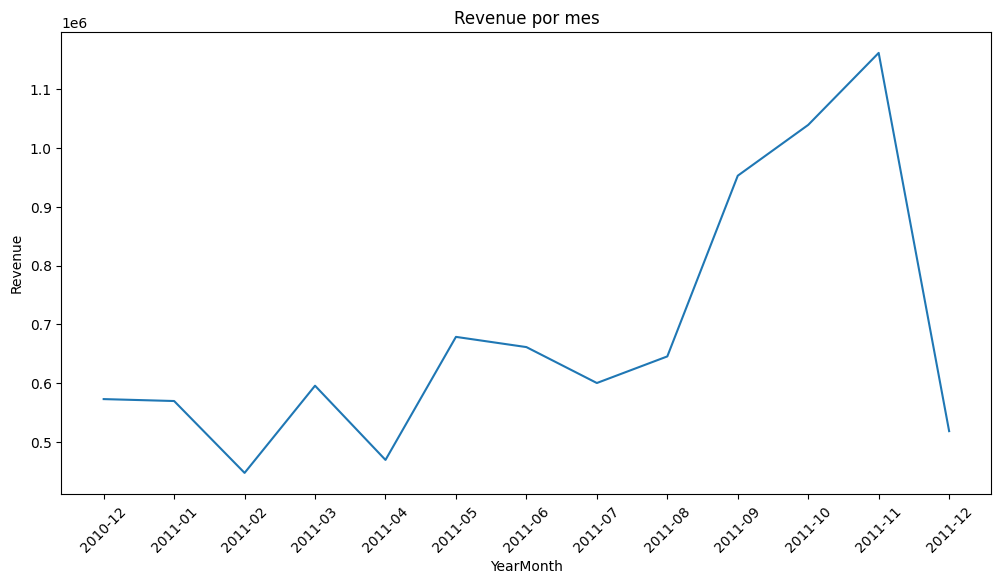

In [37]:
#Revenue por mes
monthly_revenue=df_clean.groupby("YearMonth")["Revenue"].sum().reset_index()

monthly_revenue["YearMonth"]=monthly_revenue["YearMonth"].astype(str)

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_revenue, x="YearMonth", y="Revenue")
plt.xticks(rotation=45)
plt.title("Revenue por mes")
plt.show()

Se observa una tendencia creciente en el revenue a lo largo del año, con una aceleración notable a partir del tercer trimestre. El pico en noviembre sugiere un fuerte efecto estacional, probablemente asociado a eventos comerciales como Black Friday. La caída en diciembre podría estar influenciada por la finalización de estas campañas o por la incompletitud de los datos en ese periodo.


In [38]:
#Comprobar si diciembre está completo
df_clean["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

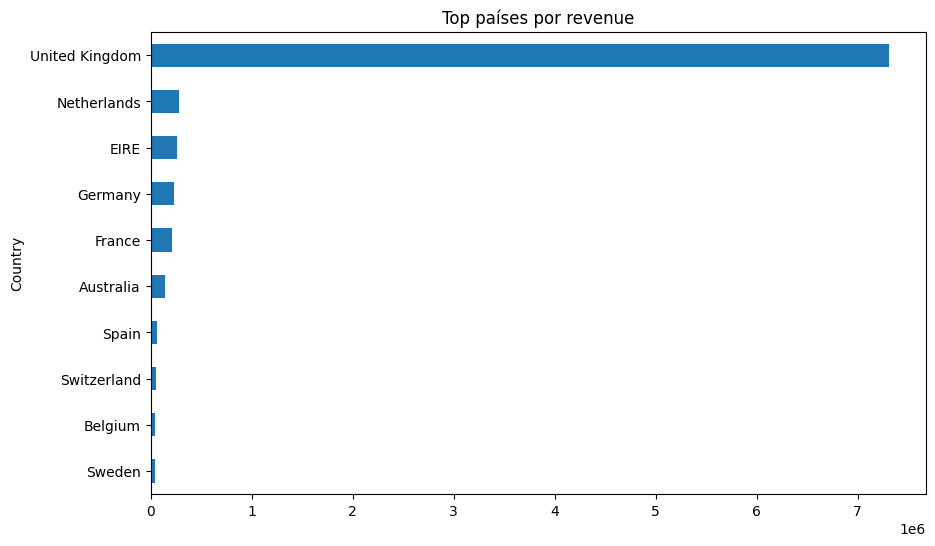

In [43]:
#Revenue por país
country_revenue = country_revenue.sort_values()

country_revenue.plot(kind="barh", figsize=(10,6))
plt.title("Top países por revenue")
plt.show()


El análisis geográfico revela una alta concentración del revenue en el Reino Unido, que domina significativamente sobre el resto de países. Esta dependencia sugiere un riesgo potencial para el negocio, ya que cualquier variación en este mercado impactaría de forma directa en el desempeño global. Al mismo tiempo, los mercados internacionales representan una oportunidad de crecimiento aún no explotada.

In [42]:
#Proporción
(df_clean.groupby("Country")["Revenue"].sum() / df_clean["Revenue"].sum()).sort_values(ascending=False)

Country
United Kingdom          0.820116
Netherlands             0.032032
EIRE                    0.029798
Germany                 0.025682
France                  0.023456
Australia               0.015544
Spain                   0.006910
Switzerland             0.006334
Belgium                 0.004623
Sweden                  0.004307
Japan                   0.004199
Norway                  0.004058
Portugal                0.003752
Finland                 0.002530
Singapore               0.002388
Channel Islands         0.002295
Denmark                 0.002127
Italy                   0.001962
Cyprus                  0.001525
Austria                 0.001144
Poland                  0.000823
Israel                  0.000810
Greece                  0.000534
Iceland                 0.000484
Canada                  0.000411
USA                     0.000402
Malta                   0.000306
Unspecified             0.000299
United Arab Emirates    0.000213
Lebanon                 0.000190
Li

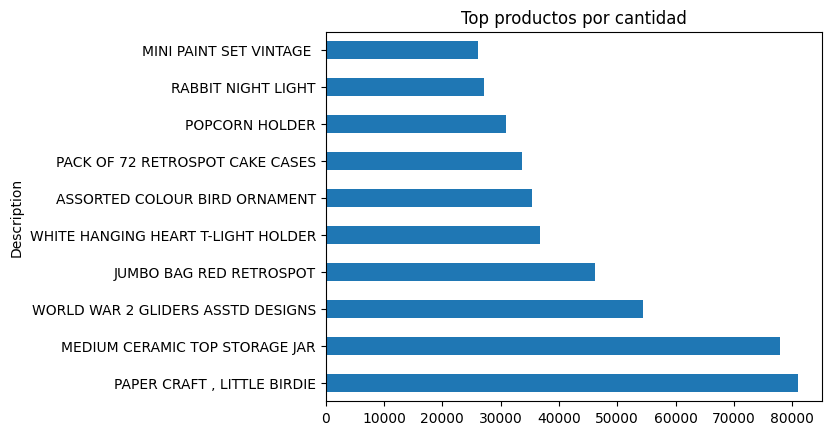

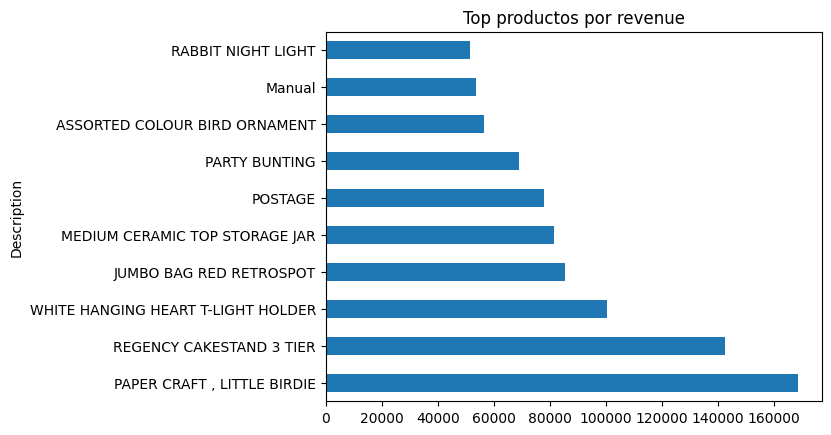

In [51]:
#Top 10 productos y Revenue
top_qty = df_clean.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
top_rev = df_clean.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

#Top por cantidad
top_qty.plot(kind="barh", title="Top productos por cantidad")
plt.show()

#Top por revenue
top_rev.plot(kind="barh", title="Top productos por revenue")
plt.show()

El análisis de productos revela diferencias claras entre volumen de ventas y generación de revenue. Algunos productos, como “MINI PAINT SET VINTAGE”, presentan alta rotación pero bajo impacto económico, mientras que otros como “RABBIT NIGHT LIGHT” combinan volumen y valor, posicionándose como productos clave para el negocio. Adicionalmente, se identificaron elementos no relacionados directamente con productos (como costos de envío), lo que sugiere la necesidad de filtrar estos registros para un análisis más preciso.

In [49]:
#Eliminando Postage y Manual
df_products = df_clean[~df_clean["Description"].str.contains("POSTAGE|Manual", case=False, na=False)]

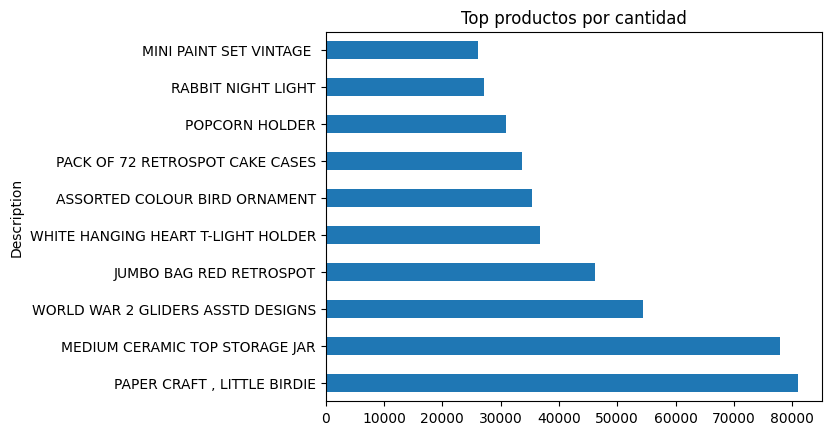

<Axes: title={'center': 'Top productos por revenue'}, ylabel='Description'>

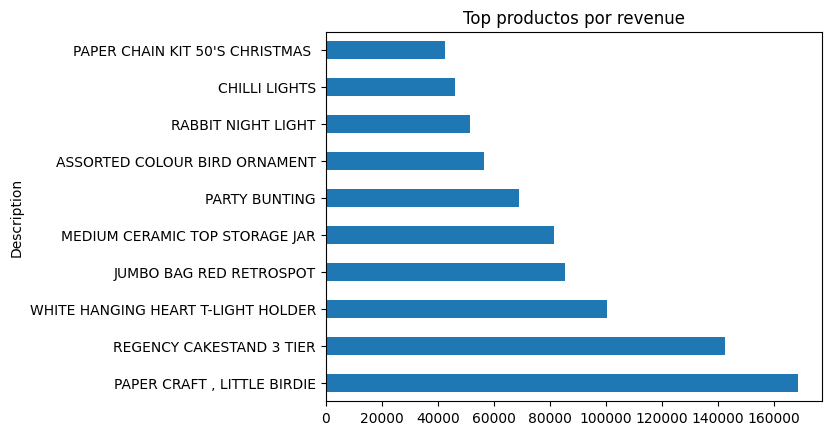

In [52]:

#Top 10 productos y Revenue
top_qty = df_products.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
top_rev = df_products.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

#Top por cantidad
top_qty.plot(kind="barh", title="Top productos por cantidad")
plt.show()

#Top por revenue
top_rev.plot(kind="barh", title="Top productos por revenue")

El análisis revela una diferencia clara entre productos de alta rotación y productos de alto valor. Mientras algunos artículos generan volumen, el revenue está principalmente impulsado por productos con mayor precio unitario. Además, se identifican productos clave que combinan ambas características, representando oportunidades estratégicas para el negocio.